In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("predictions.csv")

In [3]:
df.groupby("split").describe().T

split                     test         train    validation
prediction count  10010.000000  40039.000000  10010.000000
           mean     -25.306287    -25.377531    -25.336750
           std        3.311475      3.312517      3.313341
           min      -38.739540    -37.616604    -35.373734
           25%      -27.511499    -27.572803    -27.484928
           50%      -25.436726    -25.533716    -25.506277
           75%      -23.480602    -23.467483    -23.472349
           max      -12.835332    -10.157197    -10.146465
target     count  10010.000000  40039.000000  10010.000000
           mean     -25.339264    -25.391798    -25.312623
           std        4.178912      4.189126      4.194130
           min      -43.444355    -44.423264    -41.333706
           25%      -28.243029    -28.227485    -28.193684
           50%      -25.391379    -25.449972    -25.378772
           75%      -22.593683    -22.627635    -22.603313
           max      -10.252138     -9.003945     -7.935355

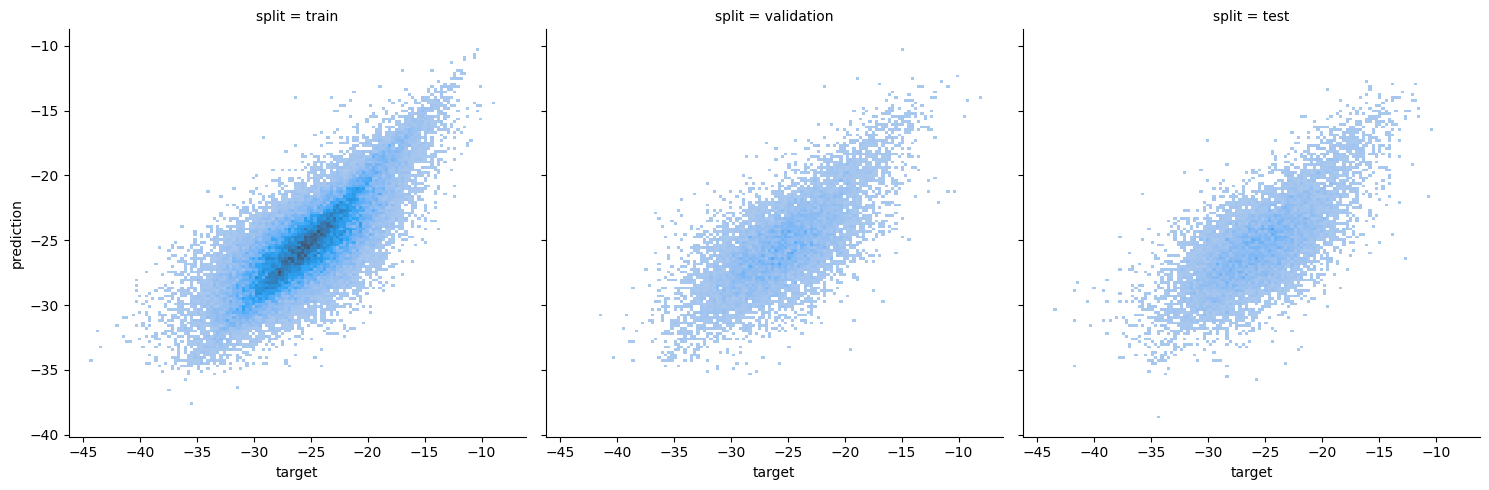

In [4]:
sns.displot(df, x="target", y="prediction", col="split")

In [5]:
def mae(values):
    return np.mean(np.abs(values["prediction"] - values["target"]))

df.groupby("split").apply(mae, include_groups=False)

split
test          2.276791
train         1.947135
validation    2.278726
dtype: float64

In [6]:
from sklearn.metrics import recall_score, precision_score

def calculate_quantile_metrics(y_true, y_pred, quantile: float):
    true_quantile = np.quantile(y_true, quantile)
    # Identify which true values are in this quantile
    true_in_quantile = y_true <= true_quantile
    
    # Use the same threshold for predicted values
    pred_in_quantile = y_pred <= true_quantile
    
    # Calculate recall
    overlap = (true_in_quantile & pred_in_quantile).sum()
    recall = overlap / true_in_quantile.sum()

    sklearn_recall = recall_score(true_in_quantile.astype("int"), pred_in_quantile.astype("int"))
    assert np.isclose(recall, sklearn_recall, atol=1e-6), \
        f"Recall mismatch at quantile {quantile}"
    

    metrics = {
        "quantile_size": true_in_quantile.sum(),
        "overlap": overlap,
        "recall": recall,
        "precision": precision_score(true_in_quantile.astype("int"), pred_in_quantile.astype("int"))
    }

    return metrics

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score


out = []
for q in [0.01, 0.05, 0.1]:
    
    for split in df["split"].unique():
        subset = df[df["split"] == split]

        targets = subset["target"]
        predictions = subset["prediction"]

        results = {
            "quantile": q,
            "split": split,
            "mae": mean_absolute_error(targets, predictions),
            "r2": r2_score(targets, predictions),
        }
        results.update(calculate_quantile_metrics(targets, predictions, q))
        out.append(results)

In [8]:
pd.DataFrame(out).sort_values(by=["split", "quantile"])

,quantile,split,mae,r2,quantile_size,overlap,recall,precision
2,0.01,test,2.276791,0.510001,101,1,0.009901,0.200000
5,0.05,test,2.276791,0.510001,501,81,0.161677,0.613636
8,0.10,test,2.276791,0.510001,1001,252,0.251748,0.560000
0,0.01,train,1.947135,0.611102,401,6,0.014963,0.545455
3,0.05,train,1.947135,0.611102,2002,403,0.201299,0.703316
6,0.10,train,1.947135,0.611102,4004,1247,0.311439,0.681793
1,0.01,validation,2.278726,0.512476,101,0,0.000000,0.000000
4,0.05,validation,2.278726,0.512476,501,98,0.195609,0.640523
7,0.10,validation,2.278726,0.512476,1001,292,0.291708,0.627957
